# Datos disponibles - EDA

In [ ]:
from pathlib import Path
import sys
## Carga de entorno
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW_DIR = Path('../data/raw/m3di')
RAW_DIR_TRAIN = RAW_DIR / 'train'
RAW_DIR_TEST = RAW_DIR / 'test'
RAW_DIR_VAL = RAW_DIR / 'val'

In [4]:
print('Cantidad de imagenes disponibles por split:')
print('train:',sum(1 for archivo in (RAW_DIR_TRAIN/'images').iterdir() if archivo.is_file()), 'imagenes')
print('test:',sum(1 for archivo in (RAW_DIR_TEST/'images').iterdir() if archivo.is_file()), 'imagenes')
print('val:',sum(1 for archivo in (RAW_DIR_VAL/'images').iterdir() if archivo.is_file()), 'imagenes')

Cantidad de imagenes disponibles por split:
train: 125000 imagenes
test: 10000 imagenes
val: 10000 imagenes


## Split: TRAIN

In [5]:
import polars as pl
df_raw_train_img = pl.read_csv(RAW_DIR_TRAIN/'latents_image.csv')
df_raw_train_txt = pl.read_csv(RAW_DIR_TRAIN/'latents_text.csv')

In [6]:
df_raw_train_img

object_shape,object_xpos,object_ypos,object_zpos,object_alpharot,object_betarot,object_gammarot,object_color,spotlight_pos,spotlight_color,background_color
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
5,2,2,0.0,0.998306,0.000365,0.41216,0.678529,0.369876,0.508168,0.476242
2,0,2,0.0,0.70499,0.888805,0.23014,0.020664,0.907154,0.410907,0.22641
0,2,1,0.0,0.233564,0.883662,0.288166,0.904964,0.008281,0.02493,0.945975
1,2,2,0.0,0.629058,0.834583,0.418968,0.911815,0.619487,0.252262,0.49592
6,0,2,0.0,0.898781,0.09749,0.360153,0.298979,0.56456,0.734886,0.229985
…,…,…,…,…,…,…,…,…,…,…
1,2,2,0.0,0.139743,0.484576,0.295481,0.841917,0.927248,0.358591,0.628631
6,2,2,0.0,0.132403,0.300693,0.759894,0.971223,0.784833,0.346635,0.975827
6,1,2,0.0,0.129382,0.151198,0.990324,0.522502,0.603335,0.095734,0.593223


In [7]:
df_raw_train_txt

object_shape,object_xpos,object_ypos,object_zpos,object_color_name,object_color_index,text_phrasing
i64,i64,i64,f64,str,i64,i64
5,2,2,0.0,"""tab:blue""",137,1
2,0,2,0.0,"""red""",120,1
0,2,1,0.0,"""tab:red""",146,1
1,2,2,0.0,"""xkcd:hot pink""",573,3
6,0,2,0.0,"""xkcd:poison green""",855,4
…,…,…,…,…,…,…
1,2,2,0.0,"""tab:pink""",144,2
6,2,2,0.0,"""tab:red""",146,0
6,1,2,0.0,"""deepskyblue""",41,3


In [10]:
print('Data images:')
for col in df_raw_train_img.columns:
    print(f'{col} tiene valores únicos {df_raw_train_img[col].n_unique()}')

Data images:
object_shape tiene valores únicos 7
object_xpos tiene valores únicos 3
object_ypos tiene valores únicos 3
object_zpos tiene valores únicos 1
object_alpharot tiene valores únicos 125000
object_betarot tiene valores únicos 125000
object_gammarot tiene valores únicos 125000
object_color tiene valores únicos 125000
spotlight_pos tiene valores únicos 125000
spotlight_color tiene valores únicos 125000
background_color tiene valores únicos 125000


In [11]:
print('Data texto:')
for col in df_raw_train_txt.columns:
    print(f'{col} tiene valores únicos {df_raw_train_txt[col].n_unique()}')

Data texto:
object_shape tiene valores únicos 7
object_xpos tiene valores únicos 3
object_ypos tiene valores únicos 3
object_zpos tiene valores únicos 1
object_color_name tiene valores únicos 100
object_color_index tiene valores únicos 100
text_phrasing tiene valores únicos 5


In [13]:
print('Cantidad de missings:')
print('Data images:')
for col in df_raw_train_img.columns:
    print(f'{col} tiene {df_raw_train_img[col].is_null().sum()} valores faltantes')

print('--------------------------------------------------------')

for col in df_raw_train_txt.columns:
    print(f'{col} tiene {df_raw_train_txt[col].is_null().sum()} valores faltantes')

Cantidad de missings:
Data images:
object_shape tiene 0 valores faltantes
object_xpos tiene 0 valores faltantes
object_ypos tiene 0 valores faltantes
object_zpos tiene 0 valores faltantes
object_alpharot tiene 0 valores faltantes
object_betarot tiene 0 valores faltantes
object_gammarot tiene 0 valores faltantes
object_color tiene 0 valores faltantes
spotlight_pos tiene 0 valores faltantes
spotlight_color tiene 0 valores faltantes
background_color tiene 0 valores faltantes
--------------------------------------------------------
object_shape tiene 0 valores faltantes
object_xpos tiene 0 valores faltantes
object_ypos tiene 0 valores faltantes
object_zpos tiene 0 valores faltantes
object_color_name tiene 0 valores faltantes
object_color_index tiene 0 valores faltantes
text_phrasing tiene 0 valores faltantes


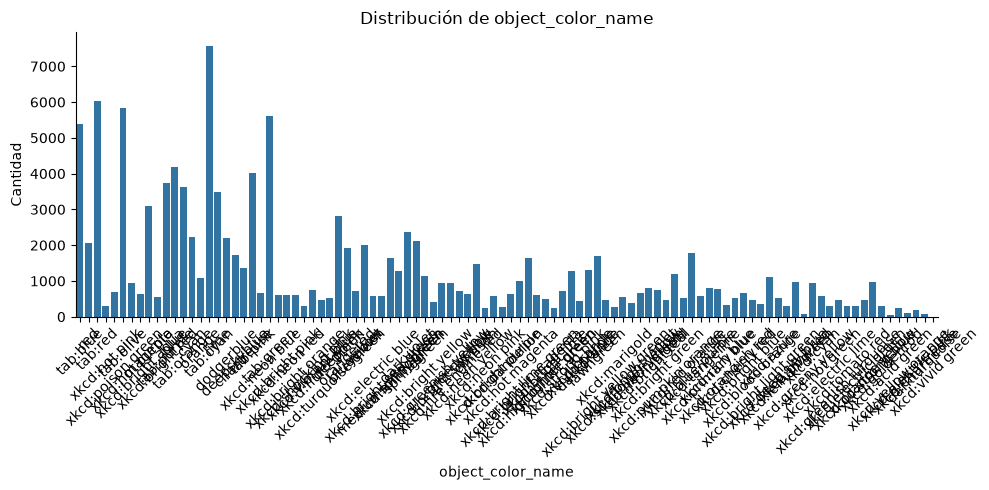

In [17]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))

sns.countplot(data=df_raw_train_txt,x='object_color_name',ax=ax,)
ax.set_title(f"Distribución de object_color_name")
ax.set_xlabel('object_color_name')
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)
sns.despine()

plt.tight_layout()
plt.show()